In [1]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [4]:
from src.models.gat import GATModel, train_gat
import numpy as np
import torch
import torch.nn as nn

/home/emmaroerty/Documents/OMSCS/DL/dl/defi_detectives/.venv/lib/python3.11/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/emmaroerty/Documents/OMSCS/DL/dl/defi_detectives/.venv/lib/python3.11/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c106detail14torchCheckFailEPKcS2_jRKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE
  import torch_geometric.typing
/home/emmaroerty/Documents/OMSCS/DL/dl/defi_detectives/.venv/lib/python3.11/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home/emmaroerty/Documents/OMSCS/DL/dl/defi_detectives/.venv/lib/python3.11/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c106detail14torchCheckFailEPKcS2_jRKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE
  import torch_geometric.typing


In [5]:
print(torch.cuda.memory_allocated() / 1024**2)

0.0


In [6]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"

In [11]:
import gc
from src.models.gat import GATModel, train_gat, evaluate_gat, create_loader
from torch_geometric import EdgeIndex
from src.losses.focal_loss import FocalLoss
from imblearn.over_sampling import SMOTE
from torch.nn import CrossEntropyLoss

node_features = np.load("../data/processed/graph/node_features.npy")
arr = np.load("../data/processed/graph/edge_index.npy")
print(arr.dtype)
print(type(arr))
edge_index = torch.LongTensor(arr.tolist())
# https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.EdgeIndex.html#torch_geometric.EdgeIndex.validate
# tg_edge_index = EdgeIndex(edge_index)
# edge_index = tg_edge_index.validate().detach().clone().to(dtype=torch.long)
in_channels = node_features.shape[1]
out_channels = 2 # binary classification
hidden_channels = in_channels
# gat = GATModel(in_channels, hidden_channels, out_channels)
X = np.load("../data/processed/baseline/X.npy")
y = np.load("../data/processed/baseline/y.npy")

# data, cls_weights = create_loader(X_train_smote, y_train_smote, known_edges)
train_loader, val_loader, test_loader, cls_weights = create_loader(X, y, edge_index)
# data, cls_weights = create_loader(X, y, edge_index)
# data_val, cls_weights_val = create_loader(X_val, y_val, edge_index)

# print(f"unique: {np.unique(data.y)}")
try:
    model = GATModel(in_channels, 16, out_channels, concat=True, heads_in=4)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9,0.999), weight_decay=0.001)
    # criterion = FocalLoss(weight=cls_weights)
    criterion = CrossEntropyLoss(weight=cls_weights).to("cuda")
    print(cls_weights)
    model, _ = train_gat(model, train_loader, optimizer, criterion, epochs=5)
    total_eval_loss, class_report_dict, class_report = evaluate_gat(model, val_loader, criterion, dataset='val')
    print(torch.cuda.memory_allocated() / 1024**2)
finally:
    print("Cleaning...")
    del train_loader, val_loader, test_loader, model, optimizer, criterion
    torch.cuda.empty_cache()
    gc.collect()


int64
<class 'numpy.ndarray'>
tensor([33179.,  4072.])
Epoch 1 / 5, Loss: 0.6989, F1 Score: 0.15897773184252562
Epoch 2 / 5, Loss: 0.3756, F1 Score: 0.03096410978184377
Epoch 3 / 5, Loss: 0.3072, F1 Score: 0.00201663725737333
Epoch 4 / 5, Loss: 0.2818, F1 Score: 0.02052052052052052
Epoch 5 / 5, Loss: 0.2637, F1 Score: 0.02005515166708448
Validation loss: 0.37447328492999077
Validation F1: 0.24334600760456274
23.9892578125
Cleaning...


In [12]:
from src.losses.focal_loss import FocalLoss
from itertools import product

# optimizer hyperparameters
learning_rates = [0.001]
weight_decays = [0.001, 0.0001]

# GAT hyperparameters
dropout = [0.5]
hidden_channels = [128, 64, 32]
heads_in = [8, 6]

# Loss hyperparameters
gamma = [0, 0.5, 5]
reweight_beta = [0.9999]

# Losses
train_loader, val_loader, test_loader, cls_weights = create_loader(X, y, edge_index)
criterions = [FocalLoss(weight=cls_weights, device="cuda"), CrossEntropyLoss(weight=cls_weights).to("cuda")]

best_f1 = 0.0
best_hyperparams = {}
num_configs = (
    len(dropout) *
    len(hidden_channels) *
    len(heads_in) *
    len(learning_rates) *
    len(weight_decays) *
    len(gamma) *
    len(reweight_beta) *
    len(criterions)
)
count = 1
hyperparams = product(learning_rates, weight_decays, dropout, hidden_channels, heads_in, gamma, reweight_beta, criterions)
for learning_rate, weight_decay, dropout, hidden, head_in, g, beta, criterion in hyperparams:
    try:
        print(f"Config {count} of {num_configs}")
        count += 1
        model = GATModel(in_channels, hidden, out_channels, concat=True, heads_in=head_in, dropout=dropout)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9,0.999), weight_decay=weight_decay)
        model, _= train_gat(model, train_loader, optimizer, criterion, epochs=25)
        train_metrics, class_report_dict, class_report = evaluate_gat(model, val_loader, criterion, dataset='val')
        
        if (class_report_dict['illicit']['f1-score'] > best_f1):
            print("New best found!")
            best_f1 = class_report_dict['illicit']['f1-score']
            best_hyperparams["learning_rate"] = learning_rate
            best_hyperparams["weight_decay"] = weight_decay
            best_hyperparams["dropout"] = dropout
            best_hyperparams["hidden_channels"] = hidden
            best_hyperparams["heads_in"] = head_in
            best_hyperparams["gamma"] = g
            best_hyperparams["beta"] = beta
            best_hyperparams["criterion"] = criterion
            print(best_hyperparams)
            print(class_report)

            with open("grid_search_gan.txt", "a") as f:
                f.write("New best found!\n")
                f.write(f"learning_rate = {learning_rate}\n")
                f.write(f"weight_decay = {weight_decay}\n")
                f.write(f"dropout = {dropout}\n")
                f.write(f"hidden_channels = {hidden}\n")
                f.write(f"heads_in = {head_in}\n")
                f.write(f"gamma = {g}\n")
                f.write(f"beta = {beta}\n")
                f.write(f"criterion = {criterion}\n")
                f.write(f"Best F1 Score: {best_f1}\n")
                f.write(f"Loss {train_metrics['total_loss']}\n")
                f.write(class_report)
                f.write("\n---------------------\n\n")
    finally:
        print("Cleaning...")
        del model, optimizer
        torch.cuda.empty_cache()
        gc.collect()


Config 1 of 72
Epoch 1 / 25, Loss: 0.4804, F1 Score: 0.2586813385045549
Epoch 2 / 25, Loss: 0.3982, F1 Score: 0.15847742256499564
Epoch 3 / 25, Loss: 0.3232, F1 Score: 0.27326581310911524
Epoch 4 / 25, Loss: 0.3221, F1 Score: 0.3404293063686358
Epoch 5 / 25, Loss: 0.3156, F1 Score: 0.2591139824642363
Epoch 6 / 25, Loss: 0.3189, F1 Score: 0.1249582358837287
Epoch 7 / 25, Loss: 0.3662, F1 Score: 0.08456098998232174
Epoch 8 / 25, Loss: 0.3232, F1 Score: 0.12553155298520158
Epoch 9 / 25, Loss: 0.3138, F1 Score: 0.08787346221441125
Epoch 10 / 25, Loss: 0.3170, F1 Score: 0.14984059511158343
Epoch 11 / 25, Loss: 0.3134, F1 Score: 0.10175377669734328
Epoch 12 / 25, Loss: 0.3065, F1 Score: 0.06458003169572107
Epoch 13 / 25, Loss: 0.3440, F1 Score: 0.03851980090889418
Epoch 14 / 25, Loss: 0.3090, F1 Score: 0.03576881134133043
Epoch 15 / 25, Loss: 0.3080, F1 Score: 0.01933506248526291
Epoch 16 / 25, Loss: 0.3148, F1 Score: 0.02327790973871734
Epoch 17 / 25, Loss: 0.3235, F1 Score: 0.0112195121951

In [13]:
best_hyperparams

{'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'dropout': 0.5,
 'hidden_channels': 32,
 'heads_in': 8,
 'gamma': 0,
 'beta': 0.9999,
 'criterion': CrossEntropyLoss()}

In [16]:
best_hyperparams_inductive = {
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "dropout": 0.5,
    "hidden_channels": 32,
    "heads_in": 4,
    "gamma": 0.5,
    "beta": 0.9999,
    "criterion": FocalLoss(weight=cls_weights, beta=0.9999, gamma=0.5, device="cuda"),
}
best_hyperparams_inductive

{'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'dropout': 0.5,
 'hidden_channels': 32,
 'heads_in': 4,
 'gamma': 0.5,
 'beta': 0.9999,
 'criterion': FocalLoss()}

In [20]:
model = GATModel(
    in_channels,
    hidden_channels=best_hyperparams_inductive['hidden_channels'],
    out_channels=out_channels,
    concat=True,
    heads_in=best_hyperparams_inductive['heads_in'],
    dropout=best_hyperparams_inductive['dropout']
)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=best_hyperparams_inductive['learning_rate'],
    betas=(0.9,0.999),
    weight_decay=best_hyperparams_inductive['weight_decay']
)
train_loader, val_loader, test_loader, cls_weights = create_loader(X, y, edge_index)

model, train_metrics = train_gat(
    model, train_loader, optimizer, best_hyperparams_inductive['criterion'], epochs=100
)
eval_metrics, class_report_dict, class_report = evaluate_gat(
    model, test_loader, best_hyperparams_inductive['criterion'], dataset='test'
)
print(class_report)

Epoch 1 / 100, Loss: 0.3876, F1 Score: 0.22555225423071953
Epoch 2 / 100, Loss: 0.2640, F1 Score: 0.2696124763705104
Epoch 3 / 100, Loss: 0.2489, F1 Score: 0.2750565184626978
Epoch 4 / 100, Loss: 0.2388, F1 Score: 0.2783807568201819
Epoch 5 / 100, Loss: 0.2124, F1 Score: 0.288270701155035
Epoch 6 / 100, Loss: 0.2137, F1 Score: 0.3480840543881335
Epoch 7 / 100, Loss: 0.1969, F1 Score: 0.3442776735459662
Epoch 8 / 100, Loss: 0.2009, F1 Score: 0.35806493675837786
Epoch 9 / 100, Loss: 0.1870, F1 Score: 0.399936768890294
Epoch 10 / 100, Loss: 0.1907, F1 Score: 0.42103902817265443
Epoch 11 / 100, Loss: 0.2166, F1 Score: 0.22661489587010236
Epoch 12 / 100, Loss: 0.1863, F1 Score: 0.40098294304712345
Epoch 13 / 100, Loss: 0.1878, F1 Score: 0.3990403838464614
Epoch 14 / 100, Loss: 0.1930, F1 Score: 0.4042722780168978
Epoch 15 / 100, Loss: 0.1843, F1 Score: 0.3993297241557102
Epoch 16 / 100, Loss: 0.1941, F1 Score: 0.3998902154521751
Epoch 17 / 100, Loss: 0.1822, F1 Score: 0.41465009810333553
Ep

In [55]:
from sklearn.metrics import roc_auc_score
test_labels = eval_metrics['targets'].detach().numpy()
test_probs = eval_metrics['probs'].detach().numpy()
masked_probs = test_probs[:,1]
roc_auc = roc_auc_score(test_labels, masked_probs)
print(f"ROC_AUC: {roc_auc}")

ROC_AUC: 0.9715095843514393
0.0 1.0 0.4622346
[4205  455]


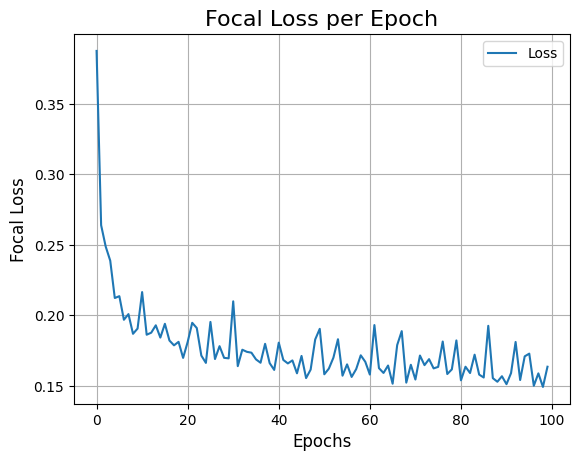

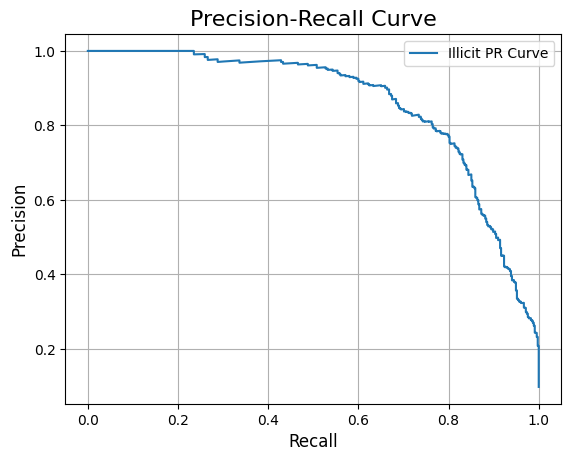

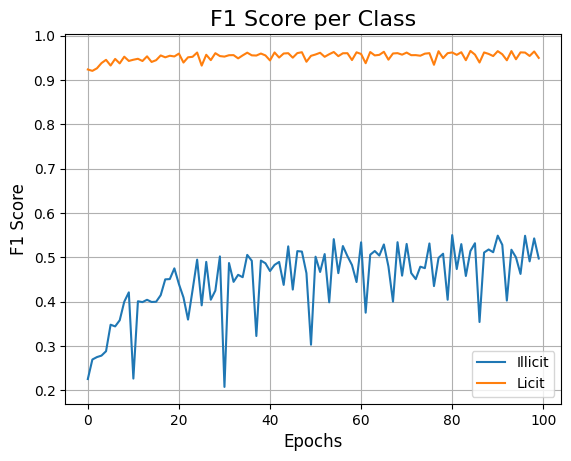

In [58]:
from src.utils.plots import plot_loss, plot_f1, plot_precision_recall

IMAGE_DIR = "../outputs/gat"

plot_loss(train_metrics['losses'], filename=f"{IMAGE_DIR}/focal_loss")
plot_precision_recall(
    eval_metrics['targets'].detach().numpy(),
    eval_metrics['probs'].detach().numpy(),
    filename=f"{IMAGE_DIR}/pr_curve"
)
plot_f1(train_metrics['licit_f1_scores'], train_metrics['illicit_f1_scores'], filename=f"{IMAGE_DIR}/f1")
# plot